## 7. SHAP & dtreeviz Explainability

Invoice-to-Payment Process Optimization — Extension

*See the [README](#) for full project overview, business problem, and dataset details.*

This notebook applies SHAP (SHapley Additive exPlanations) to the two
strongest champion models built in Notebook 6:

**Part 1 — Case-Level Throughput Prediction:** the tuned XGBoost regressor,
explaining which features drive predicted throughput time for individual
cases, and — genuinely interesting — testing whether SHAP's own feature
rankings independently confirm the same patterns already found via
XGBoost's built-in feature importance (6.3.6) and the external comparison
against [Rząd et al. (2019)](https://icpmconference.org/2019/wp-content/uploads/sites/6/2019/07/BPI-Challenge-Submission-2.pdf).

**Part 2, Model B — Vendor Award Prediction (new vendors):** the tuned
Random Forest classifier, explaining which order-level attributes drive a
vendor's predicted reliability tier, extending the feature-importance
analysis already begun in 6.4.2.

*Scope note:* Model A (existing vendors) is not covered here, given its
already-documented data-volume limitations (5.1, 6.4.1) make a deep
explainability analysis less informative than for the two stronger models
above.

Additionally, this notebook includes a dtreeviz visualization of a
representative decision tree, for structural interpretability alongside
SHAP's feature-attribution view.

## 7.1 Setup

- Install SHAP and dtreeviz
- Load trained champion models (Part 1's tuned XGBoost, Model B's tuned
  Random Forest) and their corresponding feature tables

In [41]:
# Package installs
!pip install shap --quiet
!pip install dtreeviz --quiet

In [42]:
# Imports
import shap
from dtreeviz import model as dtreeviz_model
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
from matplotlib.colors import ListedColormap

In [43]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [44]:
BASE_PATH = "/content/drive/MyDrive/Colab Notebooks/Invoice-to-Payment Process Project/BPI Challenge 2019_Data/"

In [45]:
# Strips characters ([, ], <) that break SHAP/XGBoost compatibility from
# column names
def sanitize_columns(df):
    df = df.copy()
    df.columns = [re.sub(r'[\[\]<]', '', str(col)) for col in df.columns]
    return df

In [46]:
# --- Part 1 ---
xgb_final = joblib.load(BASE_PATH + "part1_champion_model.joblib")
X_train_full = pd.read_parquet(BASE_PATH + "part1_X_train_full.parquet")
X_test = pd.read_parquet(BASE_PATH + "part1_X_test.parquet")
y_test = pd.read_parquet(BASE_PATH + "part1_y_test.parquet")['target_gr_to_clear_days']

print(f"Part 1: model expects {xgb_final.n_features_in_} features, X_train_full has {X_train_full.shape[1]}")
print(f"X_test shape: {X_test.shape}")

Part 1: model expects 158 features, X_train_full has 158
X_test shape: (17780, 158)


In [47]:
# --- Model B ---
rf_2b_final = joblib.load(BASE_PATH + "model_b_random_forest.joblib")
X_2b_test_enc = pd.read_parquet(BASE_PATH + "model_b_X_test_enc.parquet")
y_2b_test = pd.read_parquet(BASE_PATH + "model_b_y_test.parquet")['target_award_tier']
X_2b_train_full = pd.read_parquet(BASE_PATH + "model_b_X_train_full.parquet")

print(f"\nModel B: model expects {rf_2b_final.n_features_in_} features, X_2b_train_full has {X_2b_train_full.shape[1]}")
print(f"X_2b_test_enc shape: {X_2b_test_enc.shape}")


Model B: model expects 128 features, X_2b_train_full has 128
X_2b_test_enc shape: (54795, 128)


## 7.2 Part 1 — Case-Level Throughput Prediction (XGBoost)





### 7.2.1 SHAP Global Summary
- Overall feature importance across all predictions
- Direct comparison against 6.3.6's built-in feature importance ranking
- Overall pattern remains consistent with the Rząd et al. cross-validation
  established in 6.3.5

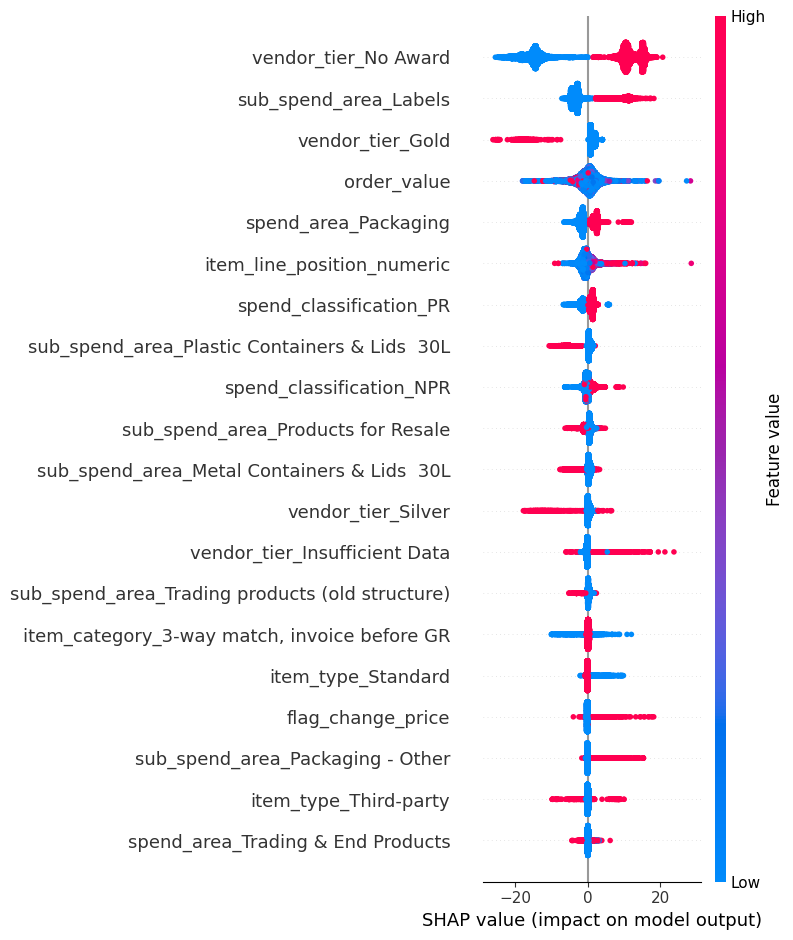

In [48]:
explainer = shap.TreeExplainer(xgb_final)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test, show=False)
plt.tight_layout()
plt.savefig('/tmp/shap_summary_part1.png', dpi=150)
plt.show()

**Key insight — SHAP global summary (Part 1):**

SHAP confirms XGBoost's built-in feature importance ranking. For the most
influential feature values, this means:

- **`vendor_tier_No Award`** and **`sub_spend_area_Labels`** are the **two most
  influential features**, matching 6.3.6 exactly
- Beyond confirming magnitude, SHAP reveals clear, business-sensible
  *direction*: being a No Award vendor (red) pushes predicted throughput
  up; being Gold (red on `vendor_tier_Gold`) pushes it down — consistent
  with every vendor-tier finding established throughout this project
- `sub_spend_area_Labels` shows a wider, more variable spread when true
  (red), suggesting Labels orders do not uniformly take longer, but are
  less predictable in general
- `order_value` shows a non-linear relationship not visible in the
  built-in importance ranking — likely an interaction effect, where
  order_value's impact depends on other features (e.g. category or vendor
  tier) rather than acting independently, a pattern tree-based models
  naturally capture but a single importance ranking cannot show; worth
  further investigation (e.g. SHAP dependence plots), though beyond this
  notebook's current scope

### 7.2.2 SHAP Individual-Case Explanation

- Explain a specific case's prediction using SHAP force/waterfall plot,
  showing which features pushed the predicted throughput up or down from
  the baseline

In [49]:
test_preds = xgb_final.predict(X_test)

# Pick the case with the longest predicted throughput, for a concrete,
# business-relevant example
longest_case_idx = np.argmax(test_preds)
print(f"Case index: {longest_case_idx}")
print(f"Predicted throughput: {test_preds[longest_case_idx]:.1f} days")
print(f"Actual throughput: {y_test.iloc[longest_case_idx]:.1f} days")

Case index: 5752
Predicted throughput: 205.3 days
Actual throughput: 187.2 days


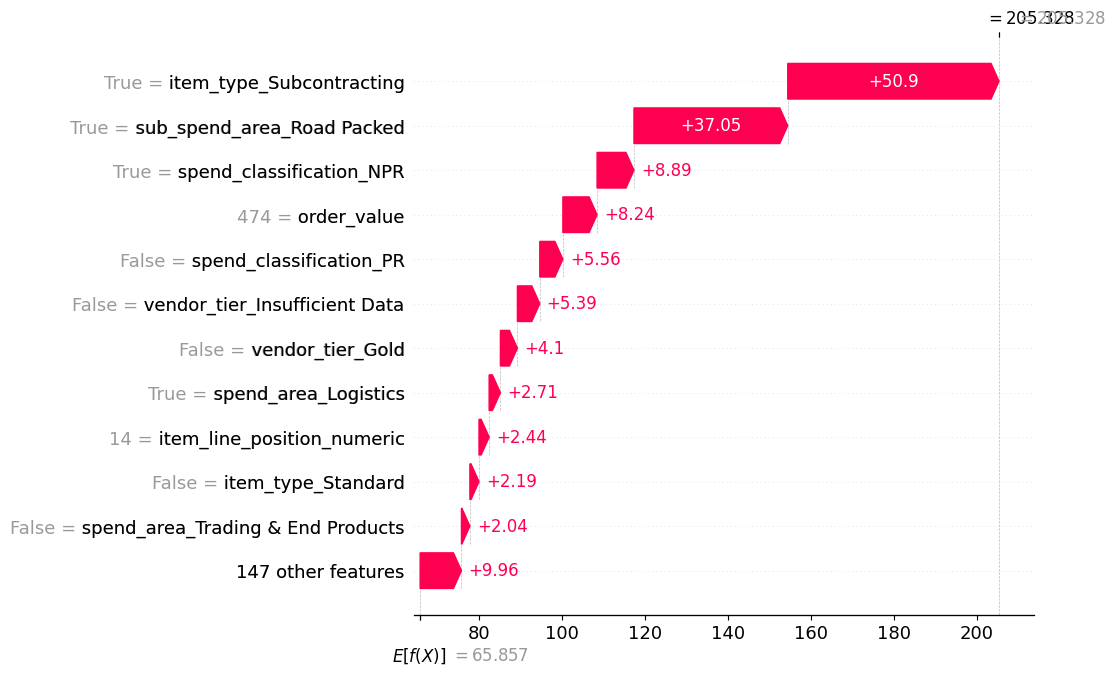

In [50]:
plt.figure()
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[longest_case_idx],
        base_values=explainer.expected_value,
        data=X_test.iloc[longest_case_idx],
        feature_names=X_test.columns.tolist()
    ),
    max_display=12,
    show=False
)
plt.savefig('/tmp/shap_waterfall_part1.png', dpi=200, bbox_inches='tight', pad_inches=0.3)
plt.show()

**Key insight — SHAP individual-case explanation (Part 1):**

For case #5752 (predicted 205.3 days, actual 187.2 days — the highest
predicted throughput in the test set), two features account for **nearly
two-thirds of the case's entire above-baseline prediction**:
`item_type_Subcontracting` (+50.9 days) and `sub_spend_area_Road Packed`
(+37.05 days) together contribute 87.95 of the 139.44 days above the
model's baseline (65.86 days) — about 63%. Neither of the two dominant
*global* features (`vendor_tier_No Award`, `sub_spend_area_Labels`)
appears among this case's top drivers — a concrete illustration that
global feature importance describes what matters *on average*, not what
drives any single prediction.

*Note:* SHAP values represent the model's own attribution relative to its
baseline, not a proven causal claim — subcontracted, road-packed shipments
are *associated with* longer predicted throughput here, which may reflect
genuine process complexity but is not independently verified as causal.
This case is drawn from the test set (a finished case with a known
outcome), distinct from the *scoring set* (6.3.7), which contains
genuinely unfinished cases with no known outcome yet.

### 7.2.3 dtreeviz — Decision Tree Visualization

- Visualize one representative tree from the XGBoost ensemble, for
  structural interpretability alongside SHAP's feature-attribution view

In [51]:
viz_model = dtreeviz_model(
    xgb_final,
    tree_index=0,
    X_train=X_test,
    y_train=y_test,
    feature_names=X_test.columns.tolist(),
    target_name='gr_to_clear_days'
)

viz_model.view(fontname='DejaVu Sans', depth_range_to_display=[0, 3])

Output hidden; open in https://colab.research.google.com to view.

**Key insight — dtreeviz structural visualization (Part 1):**

Visualizing the first three levels of a representative tree from the
XGBoost ensemble provides direct structural confirmation of the feature
importance findings established through two independent methods (6.3.6's
built-in importance, 7.2.1's SHAP summary):

- The tree's very first split — its root decision — is on `vendor_tier_No
  Award`, showing that the model's **first question** is about this
  feature when classifying any new case — confirming the overall
  dominance of this feature
- The **second level** contains  `vendor_tier_
  Gold` and `sub_spend_area_Labels` — two of the top four globally important features — further  illustrating their predictive power
- Visible distribution shifts at each split confirm these are genuinely
  meaningful divisions, not arbitrary partitions: at the **root split**, one
  branch shows a visibly wider spread reaching 300+ days, while the other
  clusters more tightly — consistent with `vendor_tier_No Award` being
  associated with both longer and more variable throughput times across
  this project

**Overall**, three independent methods — built-in feature importance, SHAP,
and direct tree structure — now consistently agree on the same dominant
drivers of predicted throughput time, with `vendor_tier_No Award`,
`sub_spend_area_Labels`, and `vendor_tier_Gold` among the top features
across all three.

*Note on reading dtreeviz plots:* each small subplot shows the target
variable's distribution against the feature's own 0/1 values on its
x-axis — correctly identifying which branch (True/False) corresponds to
which distribution requires checking both the split condition (`<`/`≥`)
*and* the 0/1 positions within that specific subplot together, rather than
assuming a fixed convention.

## 7.3 Part 2, Model B — Vendor Award Prediction (Random Forest)

### 7.3.1 SHAP Global Summary

- Overall feature importance across all predictions
- Direct comparison against 6.4.2's built-in feature importance ranking
  (`spend_classification_NPR`, `order_value` dominance)

In [52]:
X_2b_test_sample = X_2b_test_enc.sample(5000, random_state=42)

explainer_2b = shap.TreeExplainer(rf_2b_final)
shap_values_2b = explainer_2b.shap_values(X_2b_test_sample)

print(f"Number of classes: {len(shap_values_2b) if isinstance(shap_values_2b, list) else 'single array'}")
print(f"Model classes: {rf_2b_final.classes_}")

Number of classes: single array
Model classes: ['Bronze' 'No Award' 'Silver+']


In [53]:
print(f"shap_values_2b shape: {shap_values_2b.shape}")
print(f"X_2b_test_sample shape: {X_2b_test_sample.shape}")

shap_values_2b shape: (5000, 128, 3)
X_2b_test_sample shape: (5000, 128)


Class order: ['Bronze', 'No Award', 'Silver+']


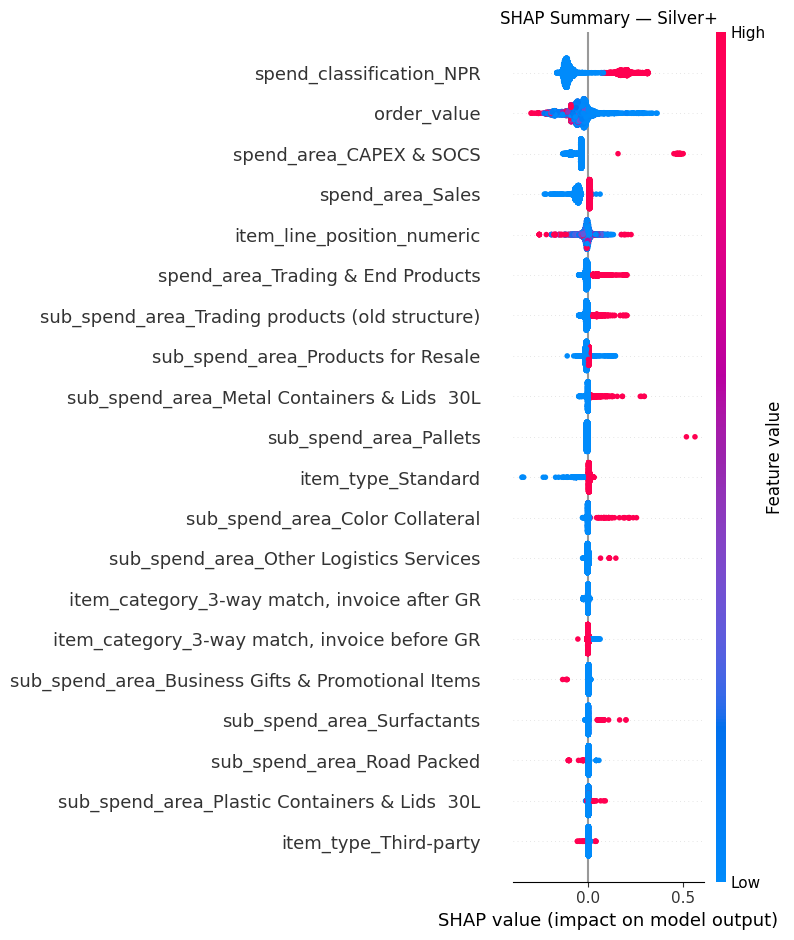

In [54]:
# Convert the 3D array into the list-of-arrays format summary_plot expects
shap_values_list = [shap_values_2b[:, :, i] for i in range(3)]  # one 2D array per class
class_names = rf_2b_final.classes_.tolist()

print(f"Class order: {class_names}")

# Global summary for Silver+ specifically (index 2, per class_names order)
shap.summary_plot(shap_values_list[2], X_2b_test_sample, show=False)
plt.title(f'SHAP Summary — {class_names[2]}')
plt.tight_layout()
plt.savefig('/tmp/shap_summary_modelb_silverplus.png', dpi=150, bbox_inches='tight')
plt.show()

**Key insight — SHAP global summary (Model B, Silver+ class):**

SHAP confirms the built-in Random Forest feature importance ranking
exactly (computed on a 5,000-row sample of the test set):

- **`spend_classification_NPR`** and **`order_value`** are the **two most
  influential features** for predicting **Silver+**, matching 6.4.2's built-in
  importance (0.310 and 0.270 respectively, 58% combined) precisely
- More specifically, this means being NPR-classified (red) clearly pushes
  predictions toward Silver+, while `order_value` shows a more complex,
  non-monotonic pattern, both very high and very low values show some
  positive association with Silver+ predictions — suggesting a real
  interaction effect rather than a simple "higher/lower is better"
  relationship, similar to the pattern already observed for Part 1's
  `order_value` feature

This is the second of two dominant global features already identified via
Random Forest's built-in importance (6.4.2) — SHAP independently confirms
both the magnitude and, for `spend_classification_NPR`, the clear direction
of the effect.

In [55]:
# Rebuild the 1,500-row sample and its SHAP values — needed for the
# multi-class bar chart below
X_2b_test_sample_small = X_2b_test_enc.sample(1500, random_state=42)

shap_values_2b_small = explainer_2b.shap_values(X_2b_test_sample_small)
shap_values_list_small = [shap_values_2b_small[:, :, i] for i in range(3)]

print(f"X_2b_test_sample_small shape: {X_2b_test_sample_small.shape}")
print(f"shap_values_list_small: {len(shap_values_list_small)} arrays")

X_2b_test_sample_small shape: (1500, 128)
shap_values_list_small: 3 arrays


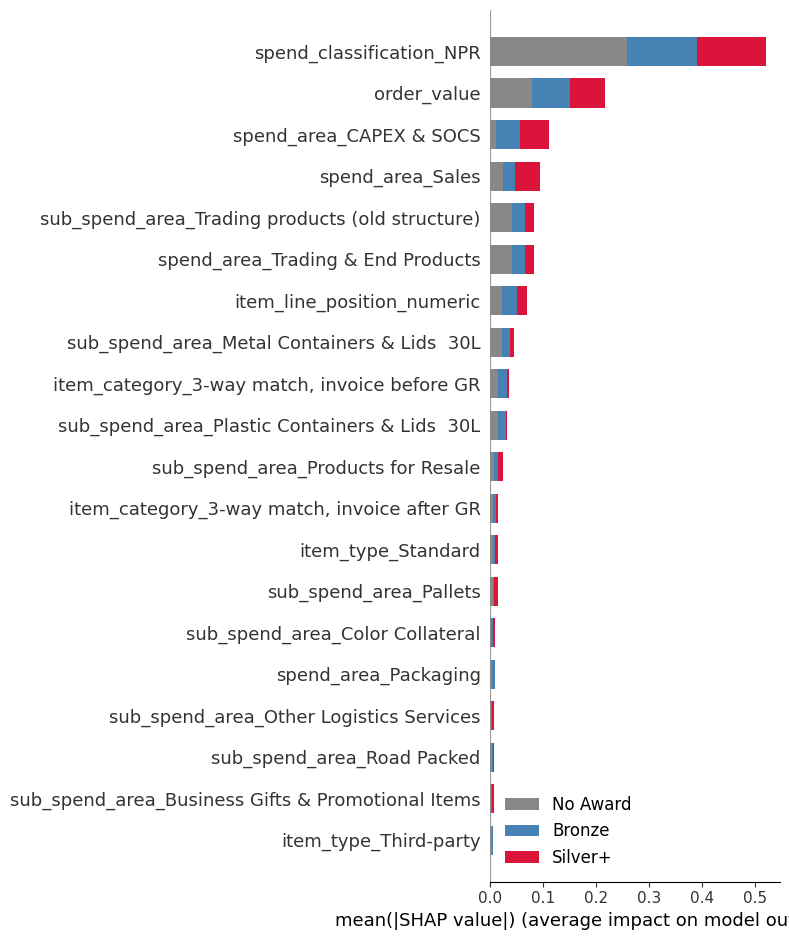

In [56]:
custom_cmap = ListedColormap(['#888888', 'steelblue', 'crimson'])

shap.summary_plot(
    shap_values_list_small, X_2b_test_sample_small,
    plot_type='bar', class_names=class_names,
    color=custom_cmap,
    show=False
)
plt.tight_layout()
plt.savefig('/tmp/shap_summary_modelb_bar.png', dpi=150, bbox_inches='tight')
plt.show()

**Key insight — SHAP multi-class comparison (Model B):**

Comparing all three classes, the multi-class SHAP bar chart (1,500-row
  sample) confirms the following pattern:
- **`spend_classification_NPR`** and **`order_value`** dominate across **all three classes** — not just Silver+, as the earlier single-class plot showed
- Each of these two top features contributes meaningfully to predictions
  for No Award, Bronze, and Silver+ alike, in similar relative
  proportions — indicating they drive the model's overall discrimination
  between tiers generally, not just one specific class

**Overall**, this strengthens the case that `spend_classification_NPR` and
`order_value` are the two genuinely foundational signals this model relies
on, consistent across every method applied (built-in
importance, single-class SHAP, and this multi-class comparison).

Among the **next tier of features**, two `spend_area` categories stand out —
`CAPEX & SOCS` and `Sales` — though with notably lower overall importance
than the top two. Unlike `spend_classification_NPR` and `order_value`,
these show class-imbalanced contributions rather than a consistent
pattern across all three tiers, with Silver+ representing the largest
share for at least `CAPEX & SOCS`. Direction of effect for these two
features was not separately examined (only checked for Silver+ via
7.3.1's single-class plot), so this pattern is noted as an observation
rather than a fully characterized finding.

### 7.3.2 SHAP Individual-Case Explanation

- Explain the three Practical Model Usage examples already built in
  6.4.2 (`4508075950_00040`, `4507030100_00430`, `4508066537_00130`),
  connecting SHAP's attribution directly to cases already discussed

In [57]:
practical_case_ids = ['4508075950_00040', '4507030100_00430', '4508066537_00130']

X_2b_specific_cases = X_2b_test_enc.loc[practical_case_ids]
shap_values_specific = explainer_2b.shap_values(X_2b_specific_cases)

print(f"Shape: {shap_values_specific.shape}")

Shape: (3, 128, 3)


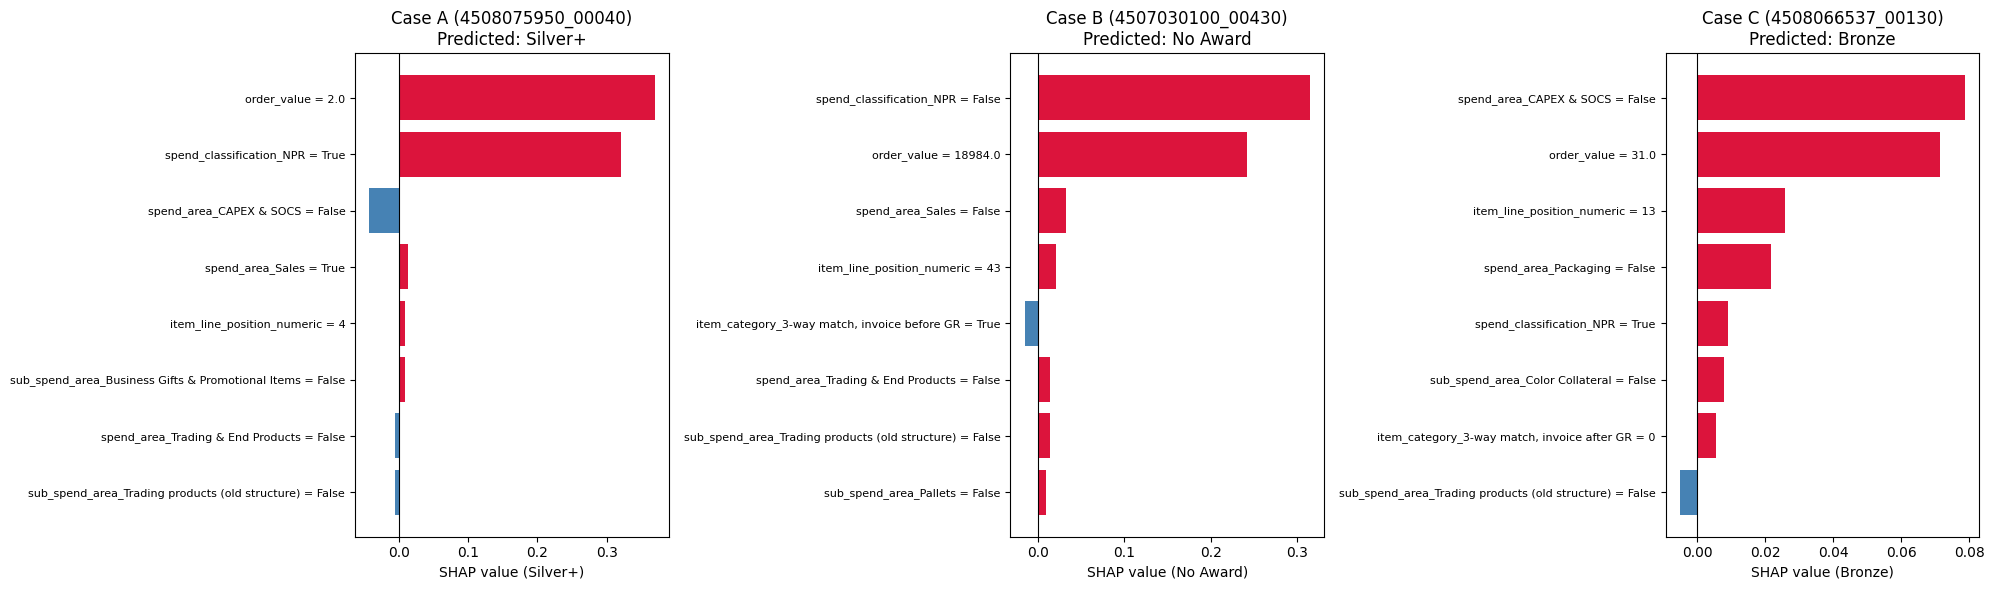

In [58]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

class_names = rf_2b_final.classes_.tolist()
predicted_class_idx = [
    class_names.index('Silver+'),   # Case A: 4508075950_00040
    class_names.index('No Award'),  # Case B: 4507030100_00430
    class_names.index('Bronze')     # Case C: 4508066537_00130
]
case_labels = ["A", "B", "C"]

for i, (case_id, class_idx, ax) in enumerate(zip(practical_case_ids, predicted_class_idx, axes)):
    case_shap = shap_values_specific[i, :, class_idx]
    case_features = X_2b_specific_cases.loc[case_id]

    top_n = 8
    top_idx = np.argsort(np.abs(case_shap))[-top_n:][::-1]

    colors = ['crimson' if v > 0 else 'steelblue' for v in case_shap[top_idx]]
    labels = [f"{X_2b_specific_cases.columns[j]} = {case_features.iloc[j]}" for j in top_idx]

    ax.barh(range(top_n), case_shap[top_idx][::-1], color=colors[::-1])
    ax.set_yticks(range(top_n))
    ax.set_yticklabels(labels[::-1], fontsize=8)
    ax.set_xlabel(f'SHAP value ({class_names[class_idx]})')
    ax.set_title(f'Case {case_labels[i]} ({case_id})\nPredicted: {class_names[class_idx]}')
    ax.axvline(0, color='black', linewidth=0.8)

plt.tight_layout()
plt.savefig('/tmp/shap_cases_modelb_combined.png', dpi=150, bbox_inches='tight')
plt.show()

**Key insight — SHAP individual-case explanations (Model B):**

- **Case A** (actual: Silver+, predicted: Silver+, 99.9% confidence ✓,
  see 6.4.2) and **Case B** (actual: No Award, predicted: No Award,
  100.0% confidence ✓): both correctly predicted, and both driven by the
  same two dominant global features identified in 7.3.1 — `order_value`
  and `spend_classification_NPR` — but in opposite directions. A very low
  order value (€2.0) and NPR classification both push strongly toward
  Silver+ (SHAP ~0.35–0.38); a much higher order value (€18,984) and
  non-NPR classification both push toward No Award. This confirms the
  global pattern holds at the individual-case level — the same two
  features driving overall predictions also drove these two specific,
  correctly-classified cases.
- **Case C** (actual: Silver+, predicted: Bronze, 53.6% vs. 38.2%
  Silver+ — a genuine close call ✗): the SHAP values here are
  roughly four times smaller than in Cases A and B (max ~0.08 vs. 0.3+) —
  no single feature provides a strong, decisive signal the way
  `order_value` did for Case A. Instead, several weak, scattered
  contributions each nudge the prediction slightly toward Bronze, none
  convincingly. This is the direct, visible reason the model's
  probabilities came out close together rather than confident — and in
  this example, the model's uncertainty was justified, since the
  prediction turned out to be wrong.

### 7.3.3 dtreeviz — Decision Tree Visualization

- Visualize one representative tree from the Random Forest ensemble, for
  structural interpretability alongside SHAP's feature-attribution view

In [59]:
# Rebuild the dtreeviz model object for Model B's Random Forest (extract
# one tree, encode target numerically)
class_names_ordered = rf_2b_final.classes_.tolist()
label_map_2b = {name: i for i, name in enumerate(class_names_ordered)}
y_2b_test_encoded = y_2b_test.map(label_map_2b)

individual_tree = rf_2b_final.estimators_[0]

viz_model_2b = dtreeviz_model(
    individual_tree,
    X_train=X_2b_test_enc,
    y_train=y_2b_test_encoded,
    feature_names=X_2b_test_enc.columns.tolist(),
    target_name='target_award_tier',
    class_names=class_names_ordered
)

print("viz_model_2b rebuilt.")

viz_model_2b rebuilt.


/usr/local/lib/python3.13/dist-packages/dtreeviz/trees.py:1651: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.


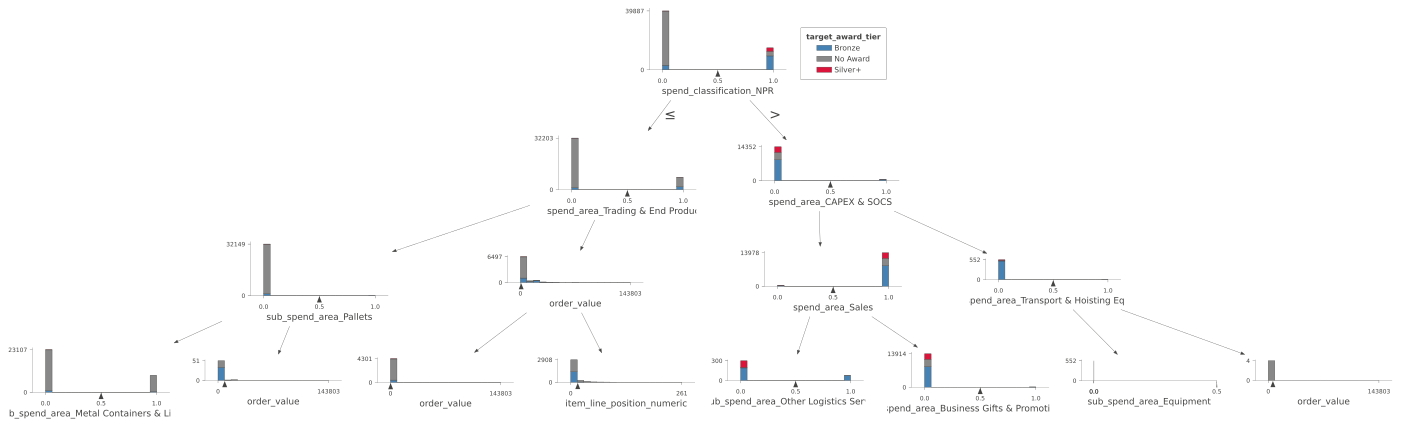

In [60]:
# Extract one representative tree from the 106-tree Random Forest ensemble,
# recoding the string target to numeric (required by dtreeviz), and
# customizing colors to match the red/blue scheme used throughout this
# notebook's SHAP visualizations

custom_colors = {'classes': [None, None, None, ['steelblue', '#888888', 'crimson']]}

viz_model_2b.view(
    fontname='DejaVu Sans',
    depth_range_to_display=[0, 3],
    colors=custom_colors
)

**Key insight — dtreeviz structural visualization (Model B):**

Visualizing the first three levels of a representative tree from the
Random Forest ensemble provides direct structural confirmation of the
feature importance findings established through two independent methods
(6.4.2's built-in importance, 7.3.1's SHAP summary):

- The tree's very first split — its root decision — is on `spend_
  classification_NPR`, showing that the model's **first question** is
  about this feature when classifying any new case — confirming the
  overall dominance of this feature, matching the exact ranking already
  established by every other method
- The **second level** contains `spend_area_Trading & End Products` and
  `spend_area_CAPEX & SOCS` — with `order_value` appearing one level
  deeper, under the `Trading & End Products` branch — together reflecting
  the same set of `spend_area`/`order_value` features already identified
  as globally important

This is the third confirmation — next to built-in feature importance and SHAP —  of the same core finding:
  `spend_classification_NPR` is not just statistically important on
  average, but structurally central to how the model actually makes
  decisions, sitting at the very top of its decision logic, with
  `order_value` and category-specific spend areas reinforcing the pattern
  just below it.

*Methodological note:* The visualized tree (index 0) was selected
arbitrarily, not chosen for agreement with SHAP's findings — Random
Forest trees are grown independently with no inherent ranking, so any
single tree is a reasonably representative, not cherry-picked, example.
That this arbitrary tree's structure matches the aggregate SHAP and
built-in importance findings so closely is itself informative, though it
has not been independently verified that this pattern holds across all
106 trees in the ensemble.

## 7.4 Key Findings Summary — SHAP & dtreeviz Explainability

This notebook applied SHAP and dtreeviz to explain the champion models from Notebook 6, testing whether their learned feature importance independently confirms the patterns already established through built-in model metrics — and whether machine learning and process-mining, two entirely different analytical approaches applied to the same dataset, arrive at similar conclusions.

**Part 1 (Case-Level Throughput Prediction, XGBoost):**

- Three independent methods — built-in feature importance (6.3.6), SHAP
  global summary, and dtreeviz's tree structure — all identify the same
  **two dominant features**: `vendor_tier_No Award` and `sub_spend_area_
  Labels`, with `vendor_tier_No Award` appearing as the tree's first root split
- SHAP's individual-case explanation revealed something the aggregate
  methods could not: for the test set's single highest-predicted case,
  neither dominant global feature appeared among its top drivers at all;
  instead, `item_type_Subcontracting` and `sub_spend_area_Road Packed`
  together explained nearly two-thirds of the case's entire above-baseline
  prediction — this demonstrates a core value of individual-case
  explainability: global importance describes what matters *on average*,
  while a waterfall diagram illustrates what drove this *specific* case

**Part 2, Model B (Vendor Award Prediction, Random Forest):**

- The same three-method pattern repeats: built-in importance (6.4.2),
  SHAP and dtreeviz all agree that `spend_classification_NPR` and
  `order_value` are the **two dominant drivers**, together accounting for 58%
  of the model's total feature importance
- SHAP's multi-class comparison showed this dominance holds consistently
  across all three award tiers, not just one specific class
- Individual-case explanations connected directly to 6.4.2's Practical
  Model Usage examples, providing a structural explanation for *why* the
  model was confident in two cases (99.9% and 100.0%) and genuinely
  uncertain in a third: the uncertain case's SHAP values were roughly
  four times smaller than the confident cases', with no single feature
  providing a strong signal — a concrete, visible reason for the model's
  hesitation, in a case where that hesitation turned out to be warranted

**In general**, the consistent, repeated agreement across three independent
explainability methods — for two different models, built with different
algorithms, addressing different problems — provides strong evidence that
the feature-importance patterns identified throughout this project
reflect genuine structure in the data, not artifacts of a measurement
approach or modeling choice. This methodological rigor (verifying
findings independently, where possible) has been applied across this
entire portfolio project.

In [61]:
# Final cell: confirms a clean, complete run of this notebook

import datetime
from zoneinfo import ZoneInfo

cet_time = datetime.datetime.now(ZoneInfo("Europe/Berlin"))

print("=" * 50)
print(f"Notebook executed successfully, top to bottom.")
print(f"Run completed: {cet_time.strftime('%Y-%m-%d %H:%M %Z')}")
print("=" * 50)

Notebook executed successfully, top to bottom.
Run completed: 2026-09-18 18:04 CEST
